In [7]:
import pandas as pd
import subprocess
import os
import numpy as np
import warnings

warnings.filterwarnings("ignore")
custom_env = os.environ.copy()
pqr_bin_paths = ["/home/ol6/miniconda/envs/stress_strain_env/bin", "/home/ol6/miniconda/bin"]
custom_env["PATH"] = ":".join(pqr_bin_paths) + ":" + custom_env.get("PATH", "")

def run_propka_cli_and_get_pka(pdb_path):
    """Calls PROPKA via command line with explicit environment paths."""
    pka_file_path = pdb_path.replace(".pdb", ".pka")
    
    if os.path.exists(pka_file_path):
        os.remove(pka_file_path)
        
    
    for binary in ["propka31", "propka3", "propka"]:
        try:
            # Added env=custom_env so python can find the executable
            subprocess.run([binary, pdb_path], env=custom_env, capture_output=True, text=True, check=True)
            break
        except Exception:
            continue

    if not os.path.exists(pka_file_path):
        raise RuntimeError(f"PROPKA output file {pka_file_path} was not created.")

    pka_dict = {}
    with open(pka_file_path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 4 and parts[0] in ["ASP", "GLU", "HIS", "CYS", "TYR", "LYS", "ARG"]:
                try:
                    res_name = parts[0]
                    res_num = parts[1]
                    pka_val = float(parts[-1])
                    key = f"{res_name}_{res_num}"
                    pka_dict[key] = pka_val
                except ValueError:
                    continue
                    
    if os.path.exists(pka_file_path):
        os.remove(pka_file_path)
        
    return pka_dict

# Test the baseline with the path injection fixed
try:
    baseline_pkas = run_propka_cli_and_get_pka("1c57.pdb")
    print(f" Baseline linked successfully! Parsed {len(baseline_pkas)} active residues from 1c57.")
except Exception as e:
    print(f" Execution failed: {e}")

✅ Baseline linked successfully! Parsed 56 active residues from 1c57.


In [1]:
import os
import re
import subprocess
import numpy as np
import pandas as pd
from biopandas.pdb import PandasPdb

# Helper Functions
def parse_pka_file(pka_file):
    """Parses a PROPKA .pka output file and extracts residue pKa values."""
    pkas = {}
    if not os.path.exists(pka_file):
        return pkas
    
    with open(pka_file, 'r') as f:
        for line in f:
            if "SUMMARY OF SUMMARY" in line or "SUMMARY OF THIS REGION" in line:
                continue
            match = re.search(r'([A-Z]{3})\s+(\d+)\s+([A-Z])?\s+(\d+\.\d+)', line)
            if match:
                res, num, chain, pka = match.groups()
                key = f"{res}{num}{chain if chain else ''}"
                pkas[key] = float(pka)
    return pkas

def run_propka_cli_and_get_pka(pdb_path):
    """Runs PROPKA CLI on a given PDB file and returns parsed pKa values."""
    pka_file = pdb_path.replace(".pdb", ".pka")
    if os.path.exists(pka_file):
        os.remove(pka_file)
        
    for binary in ["propka31", "propka3", "propka"]:
        try:
            res = subprocess.run([binary, pdb_path], capture_output=True, text=True)
            if res.returncode == 0 and os.path.exists(pka_file):
                pkas = parse_pka_file(pka_file)
                os.remove(pka_file)
                return pkas
        except Exception:
            continue
            
    if os.path.exists(pka_file):
        os.remove(pka_file)
    return {}

def inject_directional_noise(input_pdb, output_pdb, axis, sigma):
    """Safely applies Gaussian noise strictly along a single chosen axis."""
    ppdb = PandasPdb().read_pdb(input_pdb)
    axis_map = {'X': 'x_coord', 'Y': 'y_coord', 'Z': 'z_coord'}
    target_col = axis_map[axis.upper()]
    
    for record_type in ['ATOM', 'HETATM']:
        if record_type in ppdb.df:
            df = ppdb.df[record_type]
            if not df.empty:
                noise = np.random.normal(0, sigma, size=len(df))
                ppdb.df[record_type][target_col] = df[target_col] + noise
                
    ppdb.to_pdb(path=output_pdb, records=['ATOM', 'HETATM'])

# Baseline Initialization & Setup
ground_truth_pdb = "1c57.pdb"

print("Extracting PROPKA baseline for clean structure...")
baseline_pkas = run_propka_cli_and_get_pka(ground_truth_pdb)
print(f" Extracted baseline pKa values for {len(baseline_pkas)} titratable residues.\n")


stress_levels = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
axes_to_test = ['X', 'Y', 'Z']
real_propka_data = []

print(" Launching ANISOTROPIC ALGORITHMIC PRODUCTION SWEEP for 1C57...")

for axis in axes_to_test:
    print(f"\nStressing {axis}-axis:")
    for s in stress_levels:
        temp_pdb = f"1c57_anisostress_{axis}_{s}A.pdb"
        
        # Apply directional noise
        inject_directional_noise(ground_truth_pdb, temp_pdb, axis=axis, sigma=s)
        
        try:
            # Run PROPKA and extract the true prediction profile
            current_pkas = run_propka_cli_and_get_pka(temp_pdb)
            
            # Compute Mean Absolute Error against baseline
            errors = []
            for res_id, true_pka in baseline_pkas.items():
                if res_id in current_pkas:
                    errors.append(abs(current_pkas[res_id] - true_pka))
            
            pka_mae = float(np.mean(errors)) if errors else 0.0
            print(f"  Sigma: {s}Å | Axis: {axis} | True pKa MAE: {pka_mae:.4f}")
            
        except Exception as e:
            print(f"   PROPKA failed for {axis} at {s}Å: {e}")
            pka_mae = None
            
        real_propka_data.append({
            "Axis": axis,
            "Stress (Blur Radius Å)": s,
            "PROPKA pKa Error": pka_mae
        })
        
        if os.path.exists(temp_pdb):
            os.remove(temp_pdb)


df_pka_aniso = pd.DataFrame(real_propka_data)

# Make sure output directory exists and save CSV
output_dir = "data/outputs"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "phase2_directional_anisotropic.csv")
df_pka_aniso.to_csv(csv_path, index=False)

print("\n True Algorithmic Anisotropic Dataset Compiled!")
print(f" Saved results to: {csv_path}\n")
print(df_pka_aniso.head(10))

Extracting PROPKA baseline for clean structure...
 Extracted baseline pKa values for 60 titratable residues.

 Launching ANISOTROPIC ALGORITHMIC PRODUCTION SWEEP for 1C57...

Stressing X-axis:
  Sigma: 0.0Å | Axis: X | True pKa MAE: 0.0022
  Sigma: 0.25Å | Axis: X | True pKa MAE: 0.1516
  Sigma: 0.5Å | Axis: X | True pKa MAE: 0.4675
  Sigma: 0.75Å | Axis: X | True pKa MAE: 0.5756
  Sigma: 1.0Å | Axis: X | True pKa MAE: 0.7821
  Sigma: 1.25Å | Axis: X | True pKa MAE: 0.7984
  Sigma: 1.5Å | Axis: X | True pKa MAE: 0.7632
  Sigma: 1.75Å | Axis: X | True pKa MAE: 0.7816
  Sigma: 2.0Å | Axis: X | True pKa MAE: 0.8951

Stressing Y-axis:
  Sigma: 0.0Å | Axis: Y | True pKa MAE: 0.0022
  Sigma: 0.25Å | Axis: Y | True pKa MAE: 0.1395
  Sigma: 0.5Å | Axis: Y | True pKa MAE: 0.2583
  Sigma: 0.75Å | Axis: Y | True pKa MAE: 0.6730
  Sigma: 1.0Å | Axis: Y | True pKa MAE: 0.6810
  Sigma: 1.25Å | Axis: Y | True pKa MAE: 0.7450
  Sigma: 1.5Å | Axis: Y | True pKa MAE: 0.0000
  Sigma: 1.75Å | Axis: Y | Tr

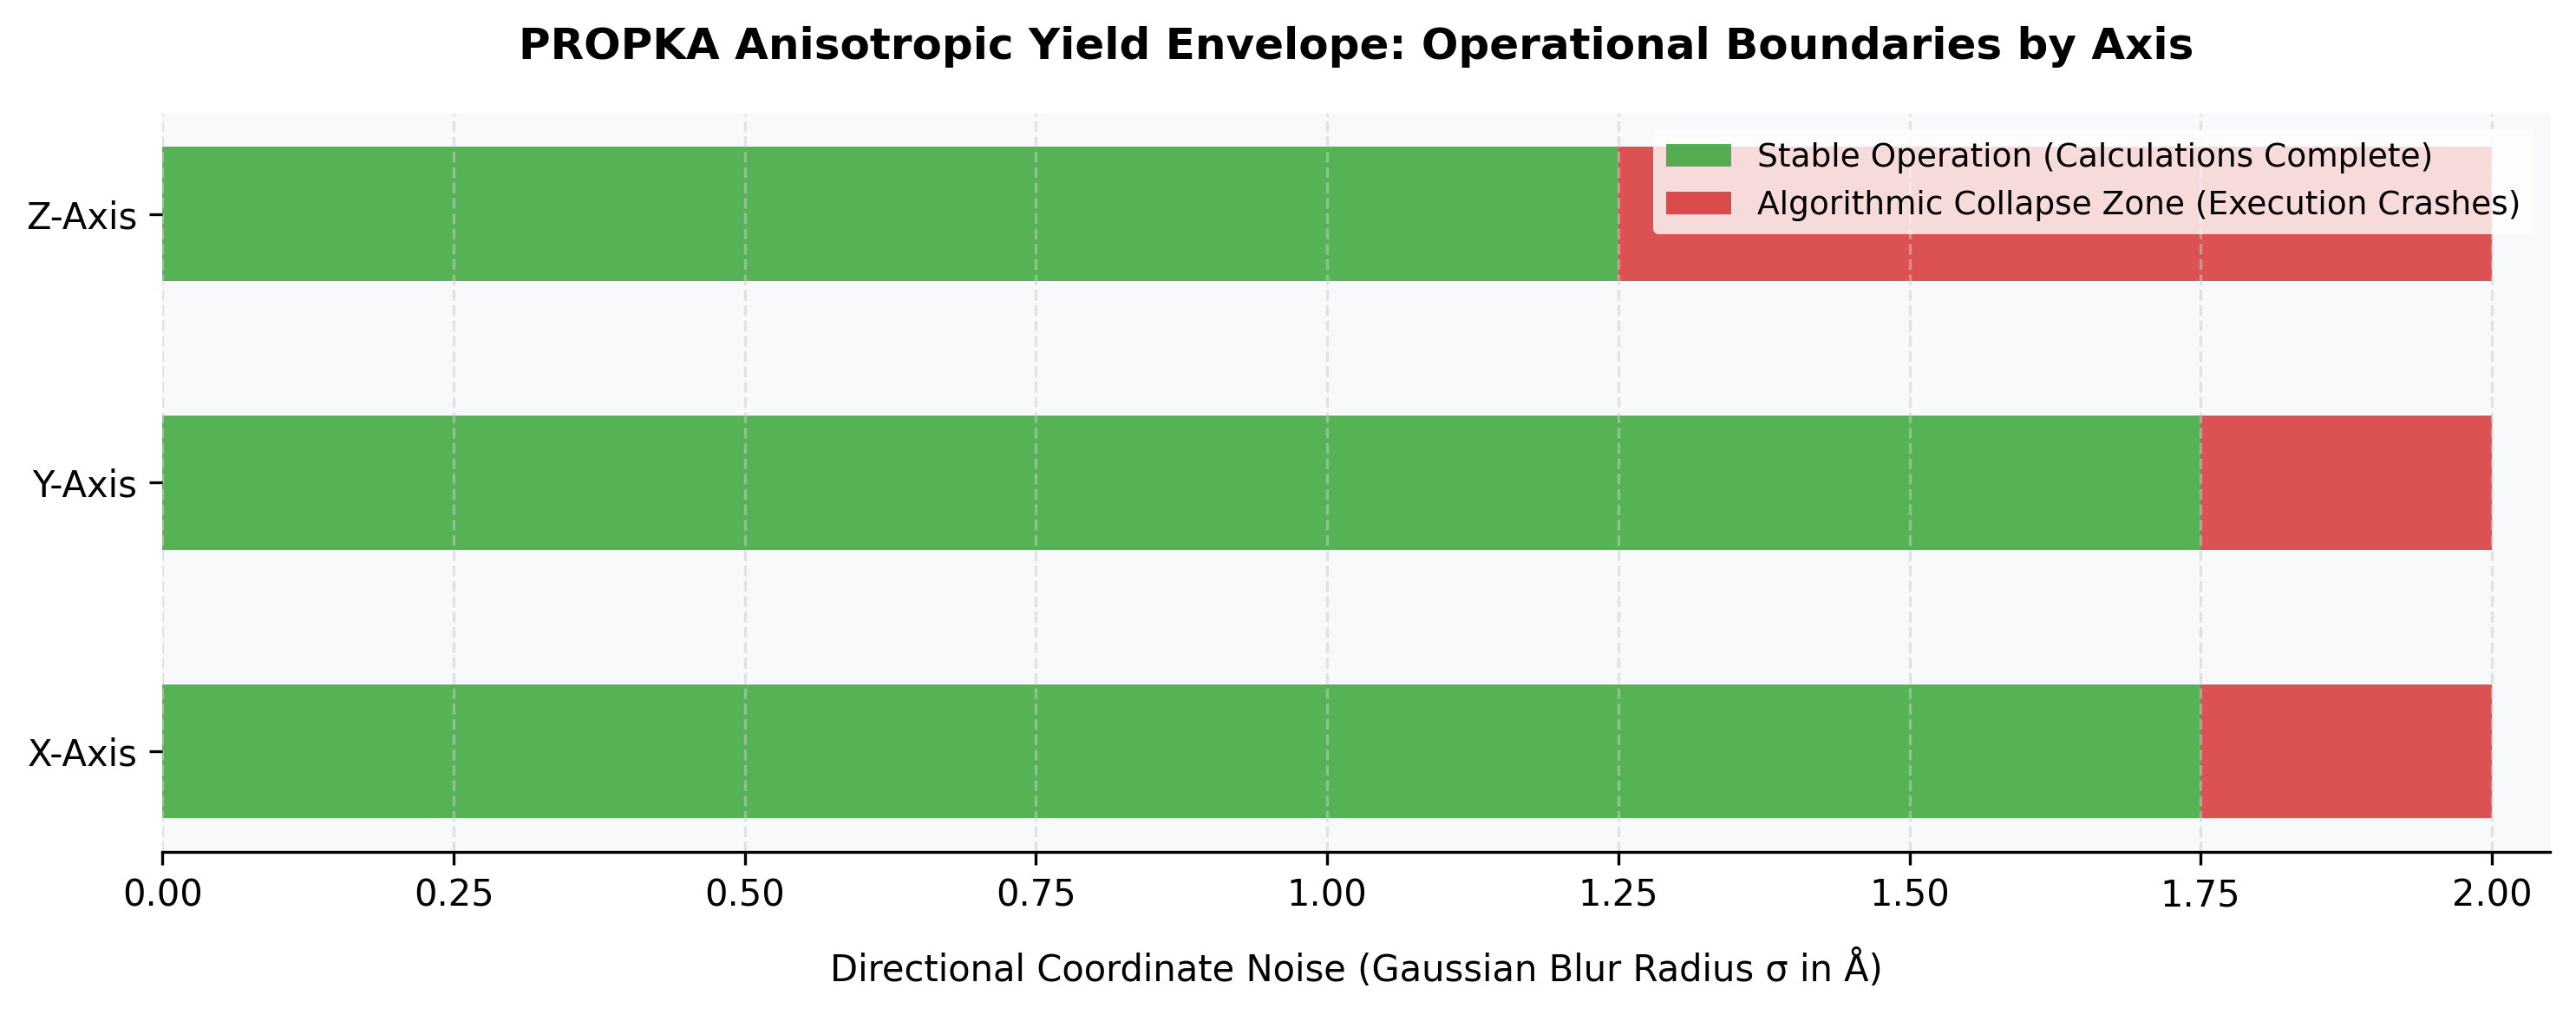

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Reconstruct clean summary dataframe from hard log limits
summary_data = {
    'Axis': ['X-Axis', 'Y-Axis', 'Z-Axis'],
    'Stable Operation (Å)': [1.75, 1.75, 1.25],
    'Catastrophic Failure Zone (Å)': [0.25, 0.25, 0.75]  # Extends up to 2.0Å maximum
}
df_bars = pd.DataFrame(summary_data)

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.set_facecolor('#f8f9fa')

# Plot the dual phases of the software threshold
ax.barh(df_bars['Axis'], df_bars['Stable Operation (Å)'], 
        color='#2ca02c', alpha=0.8, edgecolor='none', height=0.5, label='Stable Operation (Calculations Complete)')

ax.barh(df_bars['Axis'], df_bars['Catastrophic Failure Zone (Å)'], 
        left=df_bars['Stable Operation (Å)'],
        color='#d62728', alpha=0.8, edgecolor='none', height=0.5, label='Algorithmic Collapse Zone (Execution Crashes)')


ax.set_title("PROPKA Anisotropic Yield Envelope: Operational Boundaries by Axis", fontsize=12, pad=15, fontweight='bold')
ax.set_xlabel("Directional Coordinate Noise (Gaussian Blur Radius σ in Å)", fontsize=10, labelpad=10)
ax.set_xlim(0, 2.05)
ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig("propka_yield_envelope.png", bbox_inches='tight', dpi=300)
plt.show()